# Customer Churn Analysis
-----------------------
This project attempts to predict customer churn of a UK-based online retail based on sales data from Dec 1, 2009 to Dec 9, 2011. The retailer primarily sells all-occasion giftware, with many of the customers being wholesalers. 

The objective is to determine if churn can be reliably predicted & retention interventions targeted to a subset of customers, informed exclusively by order history.\
Churn is predicted using two binary classification models: 1. Logistic Regression & 2. Gradient Boosting Classification.\
GBM hyperparameters are tuned using both random search & Bayesian optimization. Model performance is compared using Avg. Precision & factor importance is accessed using Shapley values.

The base churn rate in the final (target) period is ~30%. Using the strongest model allows targeting 20%-70% of customers & achieving an approximate 50% lift in accuracy in identifying churned customers (over random selection). While the top-performing model has only moderate classification performance, it provides value as a ranking tool, enabling targeted retention strategies across various accuracy thresholds.

Even when narrowing target coverage to higher confidence customers, a model built exclusively on transaction history is not effective as a high accuracy classifier.

Data Source - UC Irvine Machine Learning Repository (Online Retail II) : https://archive.ics.uci.edu/dataset/502/online+retail+ii

In [1]:
# Import Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from datetime import datetime, timedelta
from scipy.stats import loguniform, randint, uniform, skew
import statsmodels.api as sm

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, classification_report, PrecisionRecallDisplay
from sklearn.model_selection import cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier

import optuna
import shap

# Set Display Preferences
pd.set_option('display.max_columns', None)
pd.options.display.float_format = "{:.2f}".format
np.random.seed(1)

/opt/miniconda3/envs/churn_prediction/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load data & remove duplicate entries

In [2]:
### UK Based ecom retailer sales from Jan 12, 2009 to Sep 12, 2011.
### Mainly sells unique all-occasion gift-ware.
df1 = pd.read_excel("data/online_retail_II.xlsx", sheet_name='Year 2009-2010', header=0)
df2 = pd.read_excel("data/online_retail_II.xlsx", sheet_name='Year 2010-2011', header=0)

### Note: Both excel sheets contain 2010 sales. Duplicates must be removed before concatenating.
# There is 1 week of overlap in the datasets
print('End date of File 1:', df1['InvoiceDate'].max())
print('Start date of File 2:',df2['InvoiceDate'].min())

# Remove duplicate entries 
df1 = df1[~df1["Invoice"].isin(df2['Invoice'].unique())]
# Note: achives identical result as -> df1[df1['InvoiceDate']<df2['InvoiceDate'].min()] 

### Merge the dataframes from each year
df = pd.concat([df1, df2], axis=0, ignore_index=True)

### Remove time component from Invoice Date
df['InvoiceDate'] = df['InvoiceDate'].dt.date

df_orig = df.copy()

End date of File 1: 2010-12-09 20:01:00
Start date of File 2: 2010-12-01 08:26:00


# Data Processing & Feature Engineering
--------------------------------

## Data Processiong  
 Remove null customer IDs & non-purchase invoice entries (unit price of $0 or invalid stock codes).

In [3]:
### Null Customer IDs (required to determine churn). 
### Reason for missing Customer ID is unknown. For simplicity, these entries will be excluded from the analysis. This likely creates a source of bias.
### Recomendation is to update the ordering platform to require purchasers to create an account & generate a unique Customer ID.
null_id_pct = sum(df['Customer ID'].isnull()) / len(df)
print(f'Percent of entries that are missing Customer ID: {null_id_pct*100:.2f}%')

### Some items have a price of $0. These entries will not count towards orders.
### Primarily consisting of stickers, car flags, shipping materials & invoice notes.
non_items = len(df[df['Price']==0]) / len(df)
print(f'Percent of entries that had a price of $0: {non_items*100:.2f}%')

### Examining the Stock Codes, entries starting with alphabetic characters are atypical invoice entries that do not represent merchandise sales.
### Ex. Test products, adjustments, postage, carriage, etc.
df["StockCode"] = df["StockCode"].astype(str)
stockcode = (
    df.groupby(["StockCode", "Description"])["Quantity"]
      .sum()
      .reset_index()        
      .sort_values("StockCode", ascending=False)
    )

stockcode_pct = sum(~df['StockCode'].str.match(r'^\d')) / len(df)
print(f'Percent of entries that have invalid Stock Codes: {stockcode_pct*100:.2f}%')

### Remove entries is no Customer ID, Price = $0, or  entries for Stock Codes beginning with alphabetic characters
df = df[~df['Customer ID'].isnull()]
df = df[df['Price']!=0]
df = df[df['StockCode'].str.match(r'^\d')]
df

Percent of entries that are missing Customer ID: 22.52%
Percent of entries that had a price of $0: 0.58%
Percent of entries that have invalid Stock Codes: 0.57%


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01,1.25,13085.00,United Kingdom
...,...,...,...,...,...,...,...,...
1044842,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09,0.85,12680.00,France
1044843,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09,2.10,12680.00,France
1044844,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09,4.15,12680.00,France
1044845,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09,4.15,12680.00,France


## Feature Engineering
Basic Features:
- Invoice Amount: Price * Quantity
- UK_Ind: Binary variable (1 if order country is UK, else 0)

Aggregation Features - Grouped by Customer ID & calcualted per period (n=180 days):
- Transaction Count by type (sale vs. return)
- Sale Amount (by transaction type)
- Sale Quantity (by transaction type)
- Frequency of Transactions
- First & Last Transaction Date
- Returns Percentage
- UPT (Units per Transaction)
- AUR (Avg. Unit Retail)
- AOV (Avg. Order Value)
- Product Breadth (number of unique SKUs)
- Avg. Product Breadth (unique SKUs of transaction count)
- Customer types (ex. single purches vs. return only)

Temporal Features 
- Period (per n days)
- Churn Indicator (no purchase in the next n-day length period)
- Recency (number of days from last transaction to end of period)
- Streak Length (number of consecutive periods with purchases)

### Define basic features

In [4]:
### Create a Invoice Amount column
df['Invoice Amount'] = df['Price'] * df['Quantity']

### Sales are overwhelmingly from the UK.
uk_pct = len(df[df['Country']=='United Kingdom']) / len(df)
print(f'Percent of entries sold in the UK: {uk_pct*100:.2f}%')

# Create a binary variable indicating UK vs. Global.
df['UK_Ind'] = np.where(df['Country']=='United Kingdom', 1, 0)

# Confirm country is unique to Customer ID (that a single customer order cannot have orders based in multiple countries)
country_unique_check = df.groupby(['Customer ID'], as_index=False).agg(countries = ('UK_Ind', 'nunique'))
print('Customers based in multiple markets:', country_unique_check[country_unique_check['countries']<1].shape[0])

Percent of entries sold in the UK: 90.12%
Customers based in multiple markets: 0


### Define function: Calculate aggregated features grouped by Customer ID

In [5]:
### Define aggragation function
def aggregate_by_cx(df):
    """
    Aggregate transaction data & group it by Customer ID
    """
    df = df.reset_index()
    df_aggregated = df.groupby(['Customer ID'], as_index=False).agg(
        # Country (UK) indicator
        UK_Ind = ('UK_Ind', 'max'),
        # First & last txn in the measurement period
        first_txn = ('InvoiceDate', 'min'),
        last_txn = ('InvoiceDate', 'max'),
        # Transaction Count
        total_txns = ('Invoice', 'nunique'),
        sale_txns = ('Invoice', lambda x: x[df.loc[x.index, 'Quantity'] >= 0].nunique()),
        return_txns = ('Invoice', lambda x: x[df.loc[x.index, 'Quantity'] < 0].nunique()),
        # Sales amount ($)
        total_amt = ('Invoice Amount', 'sum'),
        sale_amt = ('Invoice Amount', lambda x: x[df.loc[x.index, 'Quantity'] >= 0].sum()),
        return_amt = ('Invoice Amount', lambda x: x[df.loc[x.index, 'Quantity'] < 0].sum()),
        # Sale quantity
        total_qty = ('Quantity', 'sum'),
        sale_qty = ('Quantity', lambda x: x[df.loc[x.index, 'Quantity'] >= 0].sum()),
        return_qty = ('Quantity', lambda x: x[df.loc[x.index, 'Quantity'] < 0].sum()),
        # Variaty of SKUs
        total_skus = ('StockCode', 'nunique'),
        sale_skus = ('StockCode', lambda x: x[df.loc[x.index, 'Quantity'] >= 0].nunique()),
        # Txn Date Frequency
        total_frequency = ('InvoiceDate', 'nunique'),
        sale_frequency = ('InvoiceDate', lambda x: x[df.loc[x.index, 'Quantity'] >= 0].nunique())
        )

    # Returns Percent
    df_aggregated['return_pct'] = -1*df_aggregated['return_amt'] / (-1*df_aggregated['return_amt'] + df_aggregated['sale_amt'])
    # Units per Transaction
    df_aggregated['upt'] = df_aggregated['sale_qty'] / df_aggregated['sale_txns']
    # Average Unit Retail
    df_aggregated['aur'] = df_aggregated['sale_amt'] / df_aggregated['sale_qty']          
    # Average Order Value
    df_aggregated['aov'] = df_aggregated['sale_amt'] / df_aggregated['sale_txns']
    # SKU Mix per Order
    df_aggregated['sku_mix'] = df_aggregated['total_skus'] / df_aggregated['total_txns']

    # Replace NaN for UPT/AUR/AOV in for pure return customers
    df_aggregated.fillna(0, inplace=True)

    # Single purchase customers
    df_aggregated['cx_single_purchase'] = (df_aggregated['sale_txns'] == 1).astype(int)
    # Return only customers
    df_aggregated['cx_return_txn'] = (df_aggregated['return_txns'] > 0).astype(int)
    # Return only customers
    df_aggregated['cx_return_only'] = (df_aggregated['sale_txns'] == 0).astype(int)


    return df_aggregated

### Define function: Calculate temporal factors & apply aggregation function by customer per period

In [31]:
def calc_temporal_factors(df, n):
    """
    Split dataframe by time windows, apply group-by-customer function & calculate aggregated customer perchase features by period. 
    Then calculate temporal factors (ex. streak/recency/churn).
    n = number of days per observation period.
    """
    ### Churn will be definited by if a customer purchases in the next N days.
    ### The past N days will be used to train a model that predicts likelihood to churn. This will be called the observation window.
    ### The dataset spans 2 years, so this approach evaluates churn using a recurant sliding window approach.
    observation_days = n
    observation_periods = (df['InvoiceDate'].max() - df['InvoiceDate'].min()).days / observation_days
    observation_periods = int(math.floor(observation_periods))
    print('Number of', observation_days, 'day periods:', observation_periods, '\n')

    # Slice data by observation period starting from most recent & working backward by increments equal to the duration of the observation period
    end = df['InvoiceDate'].max()
    df_x = pd.DataFrame()
    for i in range(observation_periods):
        # Get start & end date for the given observation period.
        period_end = end
        period_start = period_end - timedelta(observation_days)
        # Create a temporary dataframe for the observation period. Aggregate by Customer ID & compute customer satistics.
        df_i = df[df['InvoiceDate'].between(period_start,period_end)]
        df_i = aggregate_by_cx(df_i)
        
        # Tag if customer churns in next period (churn defined by having at least 1 sale transaction in the next period)
        if i==0:
            churn_ind = np.nan
        else:
            churn_ind = df_i['Customer ID'].isin(df_next_period.loc[df_next_period['sale_txns'] > 0, 'Customer ID']).map({True: 0, False: 1})

        # Define new columns for Churn Indicator & Observation Period
        df_i.insert(loc=0, column='churn_ind', value=churn_ind)
        df_i.insert(loc=0, column='Period', value=observation_periods-i)
        df_i.insert(loc=0, column='Observation End', value=period_end)
        df_i.insert(loc=0, column='Observation Start', value=period_start)

        # Calculate recency from end of period to most recent trasnaction 
        df_i['recency'] = end - df_i['last_txn']
        df_i['recency'] = pd.to_timedelta(df_i['recency'])
        df_i['recency'] = df_i['recency'].dt.days

        # Concatenate each period's customer data into a single dataframe
        df_x = pd.concat([df_x, df_i], ignore_index=True)

        # Updated end date for next period
        df_next_period = df_i.copy()
        end = period_start - timedelta(days=1)

    ### Calculate number of consecutive previous periods with purchase for each Customer ID
    df_x = df_x.sort_values(['Customer ID', 'Period'])
    # Detect start of streak
    df_x['streak_start'] = df_x.groupby('Customer ID')['Period'].diff().ne(1)
    # Assign streak ids
    df_x['streak_id'] = df_x.groupby('Customer ID')['streak_start'].cumsum()
    # Compute streak length within each streak group
    streak_length = df_x.groupby(['Customer ID','streak_id']).cumcount()
    df_x.insert(loc=3, column='streak_length', value=streak_length)
    df_x.drop(['streak_start', 'streak_id'], axis=1, inplace=True)

    # Sort data
    df_x = df_x.sort_values(by=['Customer ID', 'Observation Start'],ignore_index=True)

    # Remove final period as it is only used to define churn in period N-1
    df_x = df_x[df_x['Period']<observation_periods]
    df_x['churn_ind'] = df_x['churn_ind'].astype(int)
    
    return df_x

### Apply function to calculate aggregated & temporal factors

In [7]:
### This will be our primary dataframe for analysis where churn is defined by no purchase per 180 days
df_180 = calc_temporal_factors(df, 180)
df_180

Number of 180 day periods: 4 



,Observation Start,Observation End,Period,streak_length,churn_ind,Customer ID,UK_Ind,first_txn,last_txn,total_txns,sale_txns,return_txns,total_amt,sale_amt,return_amt,total_qty,sale_qty,return_qty,total_skus,sale_skus,total_frequency,sale_frequency,return_pct,upt,aur,aov,sku_mix,cx_single_purchase,cx_return_txn,cx_return_only,recency
0,2009-12-16,2010-06-14,1,0,0,12346.00,1,2010-03-02,2010-03-02,1,1,0,27.05,27.05,0.00,5,5,0,5,5,1,1,-0.00,5.00,5.41,27.05,5.00,1,0,0,104
1,2010-06-15,2010-12-12,2,1,0,12346.00,1,2010-06-28,2010-06-28,1,1,0,142.31,142.31,0.00,19,19,0,19,19,1,1,-0.00,19.00,7.49,142.31,19.00,1,0,0,167
2,2010-12-13,2011-06-11,3,2,1,12346.00,1,2011-01-18,2011-01-18,2,1,1,0.00,77183.60,-77183.60,0,74215,-74215,1,1,1,1,0.50,74215.00,1.04,77183.60,0.50,1,1,0,144
3,2010-06-15,2010-12-12,2,0,0,12347.00,0,2010-10-31,2010-12-07,2,2,0,1323.32,1323.32,0.00,828,828,0,70,70,2,2,-0.00,414.00,1.60,661.66,35.00,0,0,0,5
4,2010-12-13,2011-06-11,3,1,0,12347.00,0,2011-01-26,2011-06-09,3,3,0,1494.16,1494.16,0.00,994,994,0,58,58,3,3,-0.00,331.33,1.50,498.05,19.33,0,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12346,2009-12-16,2010-06-14,1,0,0,18286.00,1,2009-12-16,2009-12-16,1,1,0,412.95,412.95,0.00,113,113,0,16,16,1,1,-0.00,113.00,3.65,412.95,16.00,1,0,0,180
12347,2010-06-15,2010-12-12,2,1,1,18286.00,1,2010-06-24,2010-08-20,2,1,1,725.48,833.48,-108.00,478,494,-16,53,50,2,1,0.11,494.00,1.69,833.48,26.50,1,1,0,114
12348,2009-12-16,2010-06-14,1,0,0,18287.00,1,2010-05-17,2010-05-17,1,1,0,1071.61,1071.61,0.00,732,732,0,54,54,1,1,-0.00,732.00,1.46,1071.61,54.00,1,0,0,28
12349,2010-06-15,2010-12-12,2,1,0,18287.00,1,2010-09-21,2010-11-22,3,3,0,1224.10,1224.10,0.00,694,694,0,28,28,2,2,-0.00,231.33,1.76,408.03,9.33,0,0,0,20



# Exploratory Data Analysis & Visualization
--------------------------------

## Descriptive statistics & visualizing distributions

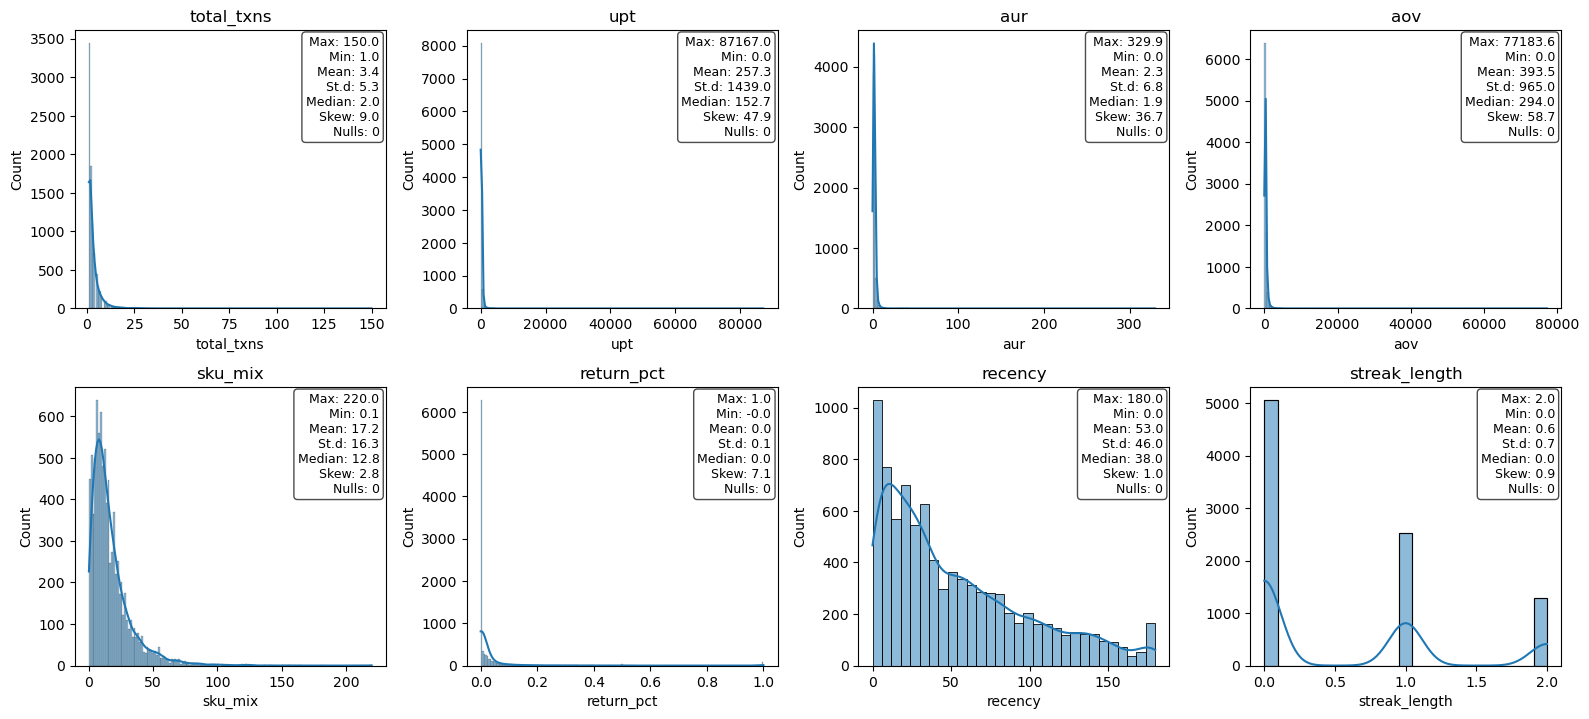

In [8]:
### Plot sistributions of key continuous variable
cont_regressors = ['total_txns', 'upt', 'aur', 'aov', 'sku_mix', 'return_pct', 'recency', 'streak_length']

# Plot distributions
plt.figure(figsize=(16, 14))                                                    # Create a 'canvas'

for i, col in enumerate(cont_regressors, 1):                                    # Loop & for each iteration:
    ax = plt.subplot(4, 4, i)                                                       # i. select a panel
    data = df_180[col]
    
    # Plot
    sns.histplot(data, kde=True, ax=ax)                                                       # ii. create a chart
    ax.set_title(col)                                                               # iii. add title/etc to subplot
    
    # Compute stats
    stats_text = (
        f"Max: {data.max():.1f}\n"
        f"Min: {data.min():.1f}\n"
        f"Mean: {data.mean():.1f}\n"
        f"St.d: {data.std():.1f}\n"
        f"Median: {data.median():.1f}\n"
        f"Skew: {skew(data):.1f}\n"          # Fisher-Pearson coefficient of skewness (|x|>1 --> highly skewed & |x|<0.5 --> fairly symetric)
        f"Nulls: {data.isna().sum():.0f}")

    # Display stats
    ax.text(
        0.98, 0.98, stats_text,
        transform=ax.transAxes,
        ha='right', va='top',
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

plt.tight_layout()
plt.show()                                                                          # iv. render prepared figure

The very long tails (statistical outliers) & heavy skewness are a byproduct of having two different customer bases with differing behaviour (consumer vs. wholesaler).\
The range & distribution of each variable is within expectations.

Note on recency: Would expect the distribution to be flat for single purchase customers, but becomes skewed toward more recent due to multiple purchase customers.\
Note on streak_length: due to limitations of the data, all customers have a streak of 0 in our first period. Lack of historical data inflates the number of 'new customers'.

Note: Extreme values are problematic for convergence & consistency of logistic regression algorithm.\
Solution - Take the signed natural log of input factors to:  
- Compresses extreme values & stabalize variance --> reduces leverage of exteme values & instability in modeling
- If a variable is highly skewed, its relationship to the log-odds of churn is likely non-linear
- Reduces skewness
- Spreads dense peaks  

Improving the performance of the logistic regression model (linearity & outlier influence on coefficients) & gradient boosting model (improved split quality)
- Note: using a signed log transformation due to zero/negative values, achieving the similar transformation effects as taking the natural log
- For a log transformation: 1% increase in 𝑥, the signed log odds change by approximately β/100.
- However, for signed-zero shifted-log odds, the effect of x on the log odds is not constant in percentage terms. Instead, the marginal effect decreases as |𝑥| increases, meaning changes in smaller values of 𝑥 have a larger impact on the model than changes in large values.

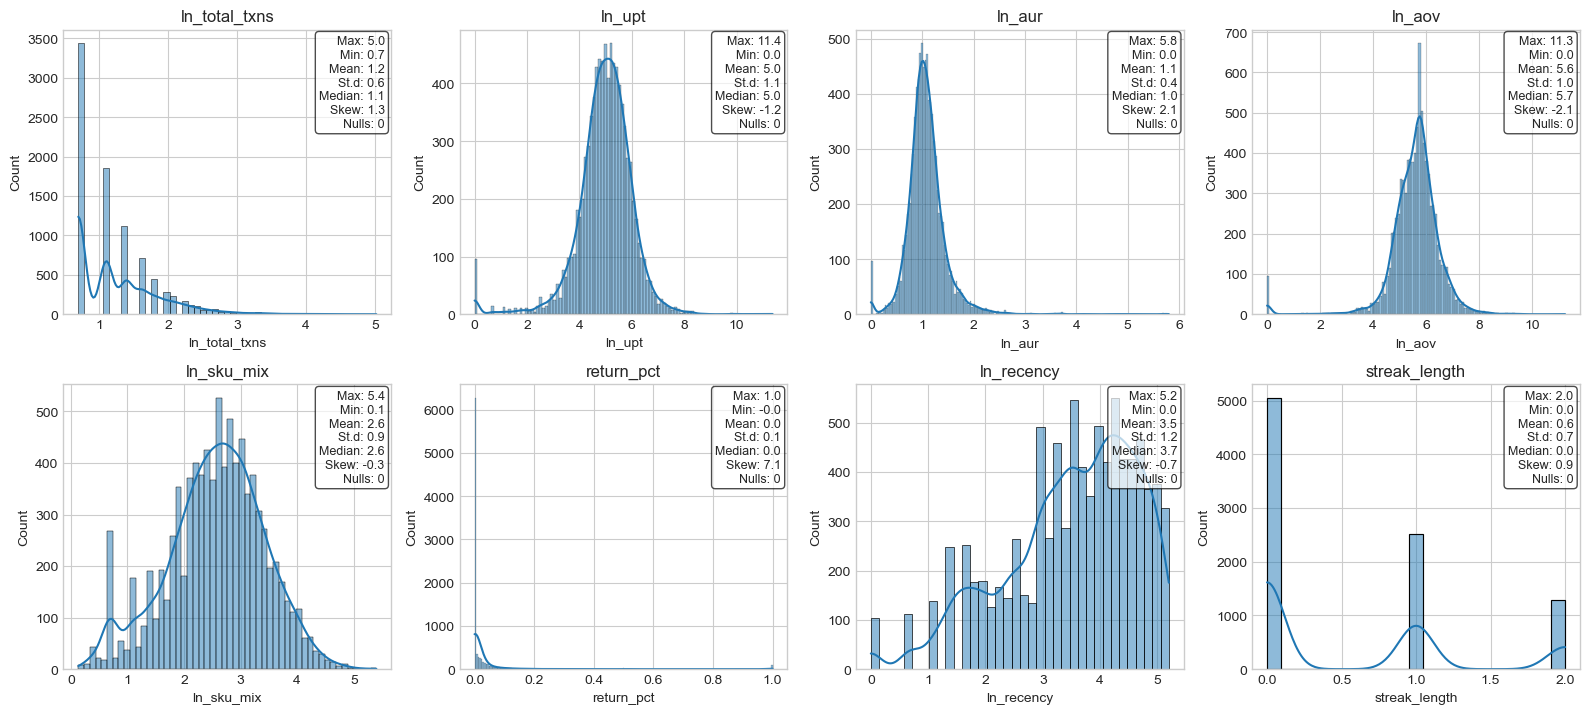

In [32]:
### Take signed natural log of continuous, skewed columns
# (Reduces  impact of extreme outliers, making  variance of the data more constant across its range --> critical for logistic regression algo.)
cols = ['total_txns', 'upt', 'aur', 'aov', 'sku_mix', 'recency']
def sign_log_cols(df, cols):
    """
    Take Signed Logarithmic Transformation {sign(x) * log(1 + |x|)} of continuous, skewed variables.

    Note: Handling Skewed Data with Negatives, is Sign & Zero-Value Preserving
    """
    for c in cols:
        #df.loc[:, f"ln_{c}"] = np.log(df[c])
        df.loc[:, f"ln_{c}"] = np.log(abs(df[c])+1) * np.sign(df[c])
    return df

sign_log_cols(df_180, cols)

### Distribution of key variable
cont_regressors = ['ln_total_txns', 'ln_upt', 'ln_aur', 'ln_aov', 'ln_sku_mix', 'return_pct', 'ln_recency', 'streak_length']

# Re-plot distributions
plt.figure(figsize=(16, 14))                                                    # Create a 'canvas'

for i, col in enumerate(cont_regressors, 1):                                    # Loop & for each iteration:
    ax = plt.subplot(4, 4, i)                                                       # i. select a panel
    
    #data = df_180[col].dropna()#
    data = df_180[col]
    
    # Plot
    sns.histplot(data, kde=True, ax=ax)                                                       # ii. create a chart
    ax.set_title(col)                                                               # iii. add title/etc to subplot
    
    # Compute stats
    stats_text = (
        f"Max: {data.max():.1f}\n"
        f"Min: {data.min():.1f}\n"
        f"Mean: {data.mean():.1f}\n"
        f"St.d: {data.std():.1f}\n"
        f"Median: {data.median():.1f}\n"
        f"Skew: {skew(data):.1f}\n"          # Fisher-Pearson coefficient of skewness (|x|>1 --> highly skewed & |x|<0.5 --> fairly symetric)
        f"Nulls: {data.isna().sum():.0f}")
    # Display stats
    ax.text(
        0.98, 0.98, stats_text,
        transform=ax.transAxes,
        ha='right', va='top',
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

plt.tight_layout()
plt.show()                                                                          # iv. render prepared figure

After applying signed log transformation, skewness is substantially reduced, with compressed tails and improved spread of central regions.

Transforming the data diminishes the interpretability in the original scale. However, the gains in stability and predictive performance outweigh this limitation.

Notes:
- The spike at zero for UPT, AUR & AOV represents return-only customers.
- The spike for ln_sku_mix represents customers who only purchased 1 skew {ln(|1|+1)≃0.7}

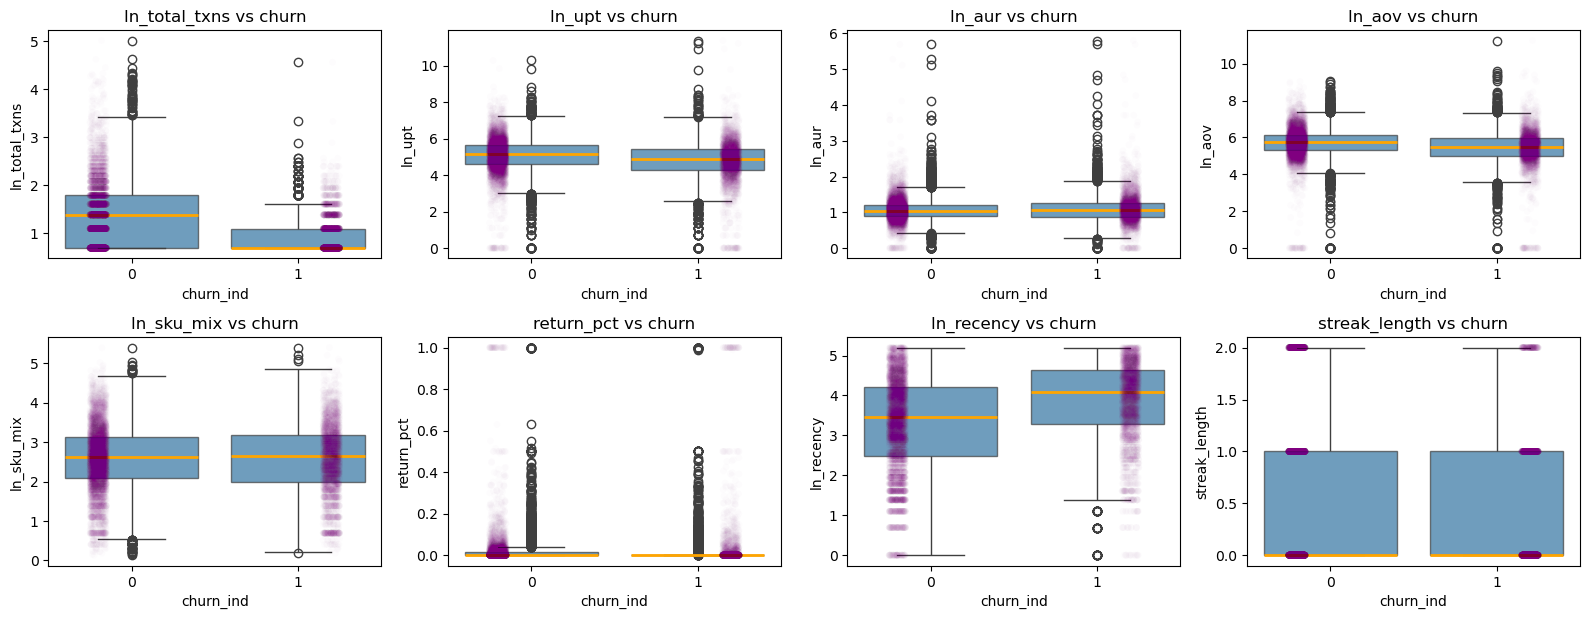

In [10]:
### Compare input factor distributions for churned vs non-chruned customers.
plt.figure(figsize=(16, 12))
for i, col in enumerate(cont_regressors, 1):
    plt.subplot(4, 4, i)
    #ns.boxplot(x="churn_ind", y=col, data=df_180)
    sns.boxplot(data=df_180,
                x="churn_ind",
                y=col,
                medianprops={"color": "orange", "linewidth": 2},
                boxprops={"alpha": 0.7}
                )
    sns.stripplot(
                data=df_180,
                x="churn_ind",
                y=col,
                palette=["purple", "purple"],
                alpha=0.01,
                hue="churn_ind",
                dodge=True,
                legend=False,
                jitter=True

            )
    plt.title(f"{col} vs churn")
plt.tight_layout()
plt.show()

The following can be derived from visually comparing the distributions & medians of each factor for churned vs non-churned customers:
- The largest discrepancies in distributions between groups are for transaction count, followed by recency.\
    (Indicates the majority of churners are single purchase customers)
- There is little to no visual difference between groups for UPT, AUR, AOV, SKU mix, return percent, or streak length.

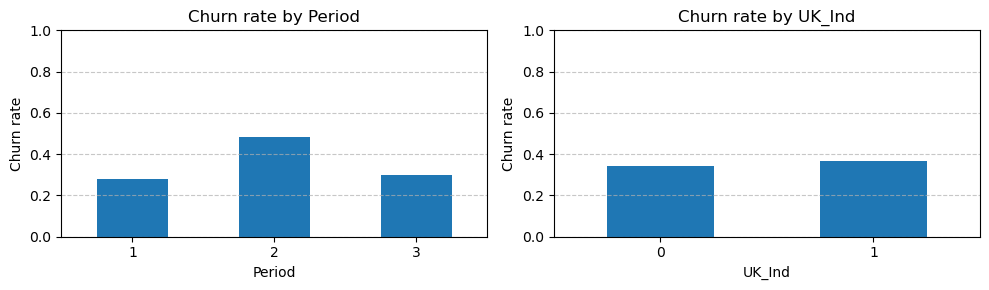

In [11]:
### Plot churn rates across time  geography for trends in seasonality, persistent change in churn accross time or geographical bias.
cat_vars = ["Period", "UK_Ind"]
fig, axes = plt.subplots(1, len(cat_vars), figsize=(10, 3))

for i, col in enumerate(cat_vars):

    churn_rate = df_180.groupby(col)["churn_ind"].mean()
    churn_rate.plot(kind="bar", ax=axes[i], title=f"Churn rate by {col}")
    
    axes[i].set_ylabel("Churn rate")
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)
    axes[i].set_ylim(0, 1) 

plt.style.use("default") 
plt.tight_layout()
plt.show()

The spike in churn in Period 2 suggests there might be a seasonality component to churn. However, more historical data is required to determine if this is a pattern that can be modelled or if the spike is due to an isolated incident or economic factor. Geography does not appear to be a significant factor in predicting churn.

## Visualizing relationships between variables

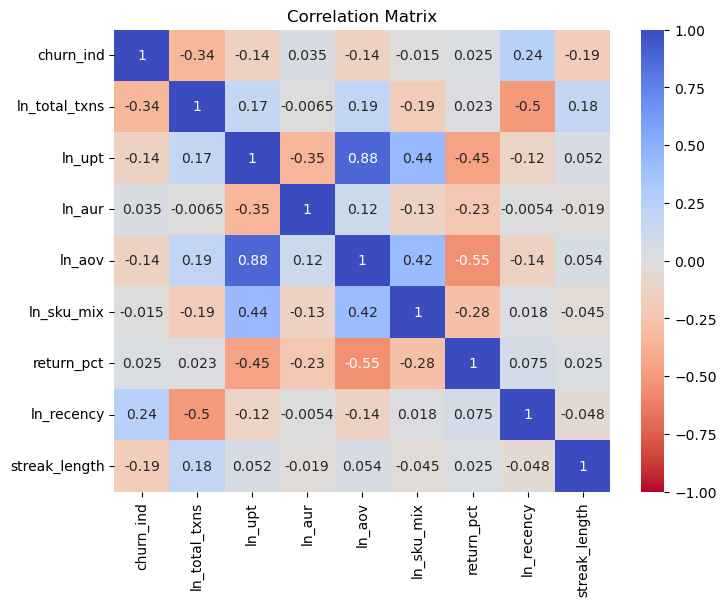

In [12]:
### Correlation Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    df_180[['churn_ind']+ cont_regressors].corr(),
    #mask=mask,
    annot=True,
    cmap="coolwarm_r",
    vmin=-1,
    vmax=1
)
plt.title("Correlation Matrix")
plt.show()

Again, we see Churn is most highly correlated with transaction count (frequency) as well as recency.\
Note: Frequency & recency are moderately correlated with each other, which is expected \
(If a customer makes multiple purchases over a period, it is more likely that one of those purchases will be closer to the end of the period)\
\
AUR, SKU mix, & return percentage appear to be almost completely uncorrelated with Churn.

There is an issue of multicollinearity between UPT, AUR & AOV. Therefore, one of these needs to be removed. 

In [13]:
### A correlation matrix was used to assess multicollinearity among predictors.
# Remove AOV as it is the product of AUR & UPT 
cont_regressors.remove('ln_aov')

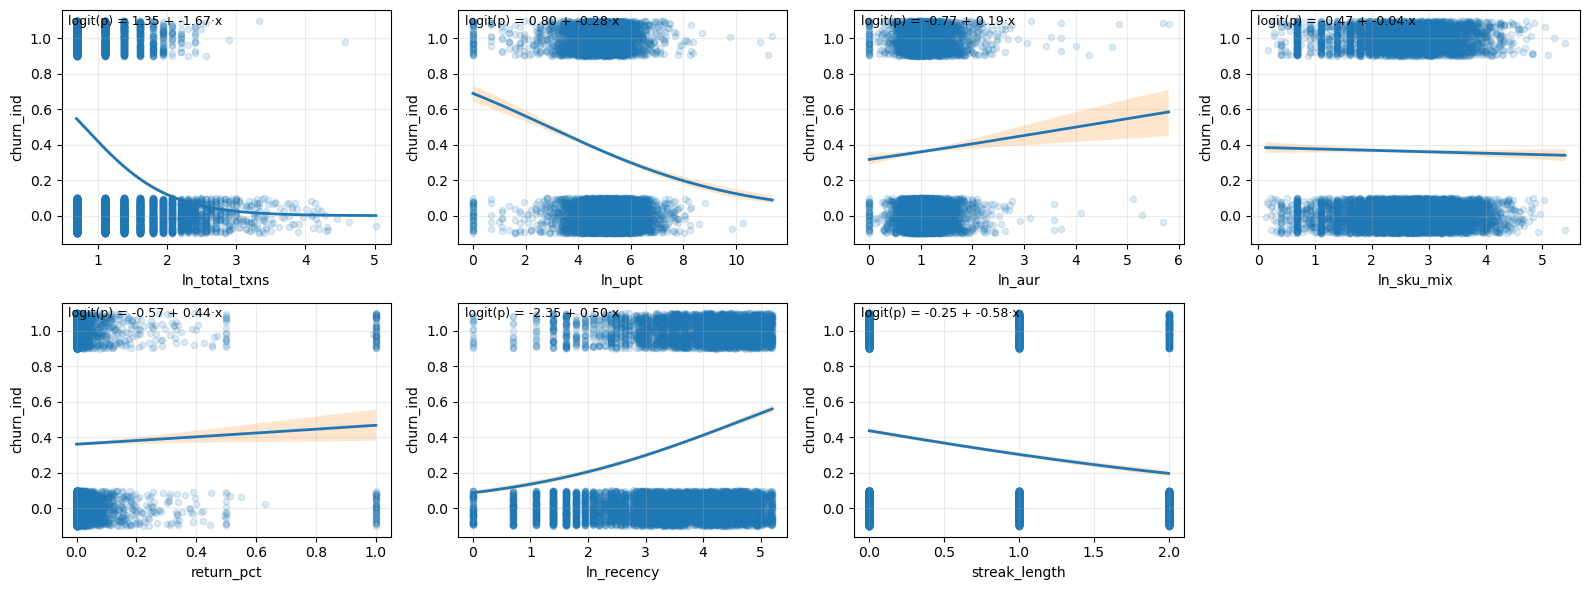

In [14]:
### Univariate partial dependence logistic regression plots
# Define subplot grid
n_cols = 4
n_rows = int(np.ceil(len(cont_regressors) / 4))                         # np.ceil rounds up to the nearest integer
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows))      # Create figure with a grid of subplots
axes = axes.flatten() # Flatten axes array so we can index it easily (1D instead of 2D)
for i, col in enumerate(cont_regressors):
    ax = axes[i]  # Select subplot axis
    x = df_180[col]
    y = df_180['churn_ind']

    # Fit logistic regression
    X = sm.add_constant(x) # Add intercept term
    model = sm.Logit(y, X).fit(disp=False)                              # Fit model (.fit=estimate coeficcients // disp=False suppresses print output)

    # Create grid of x values
    xg = np.linspace(np.min(x), np.max(x), 300)                   # Plot 300 points from min to max x to create a smooth line

    # Compute predicted probabilities
    Xg = sm.add_constant(xg)        # Add constant for prediction
    eta = Xg @ model.params         # Linear predictor: eta = Xβ        # Note: @ = matrix multiplication ()
    p = 1 / (1 + np.exp(-eta))      # Logistic function: p = 1 / (1 + e^-eta) --> converts linear predictor to a probability

    # Compute 95% confidence interval
    cov = model.cov_params()        # Covariance matrix of coefficients
    # Standard error of linear predictor
    se_eta = np.sqrt(np.sum((Xg @ cov) * Xg, axis=1))
    # Lower and upper bounds (converted to probability scale)
    z = 1.96                        # z-score for 95% CI
    lo = 1 / (1 + np.exp(-(eta - z * se_eta)))
    hi = 1 / (1 + np.exp(-(eta + z * se_eta)))

    # Add jitter to churn_ind for clearer visualization of data density
    rng = np.random.default_rng(0)
    yj = y + rng.uniform(-0.1, 0.1, size=len(y))

    # Create plots
    ax.scatter(x, yj, alpha=0.15, s=20)                         # Scatter (data points)
    ax.plot(xg, p, linewidth=2, label="Logistic fit")           # Logistic curve
    ax.fill_between(xg, lo, hi, alpha=0.2, label="95% CI")      # Confidence band
    ax.set_xlabel(col)
    ax.set_ylabel("churn_ind")
    ax.grid(True, alpha=0.25)

    # Annotate model equation
    b0, b1 = model.params
    ax.text(
        0.02, 0.98,
        f"logit(p) = {b0:.2f} + {b1:.2f}·x",
        transform=ax.transAxes,
        va="top",
        fontsize=9 )


# Remove unused subplots
for j in range(len(cont_regressors), len(axes)):
    fig.delaxes(axes[j])


plt.tight_layout()
plt.show()

Univariate partial dependence plots suggest the following:
1. Transaction count per period (frequency) is the strongest driver of retention/churn. This effect is likely reflected again with the inverse slope of recency.
2. Larger basket size (UPT) is a predictor of lower shurn likelihood.
3. Slight positive slope for AUR suggests higher price point customers are less likely to return. \
 (Both UPT & AUR might reflect the difference between wholesale customers & regular consumers)
4. Return percent, SKU mix & streak length show very low predictive power.
5. All relationships have low separation (heavy overlap between retained & churned) spanning the entire range space. Result is that model is probabilistic & not deterministic when predicting churn.\
 (Therefore, the model will be limited in predicting 'high confidence' churners)

Churn risk is continuous and diffuse, not concentrated in a clearly separable subset of customers.

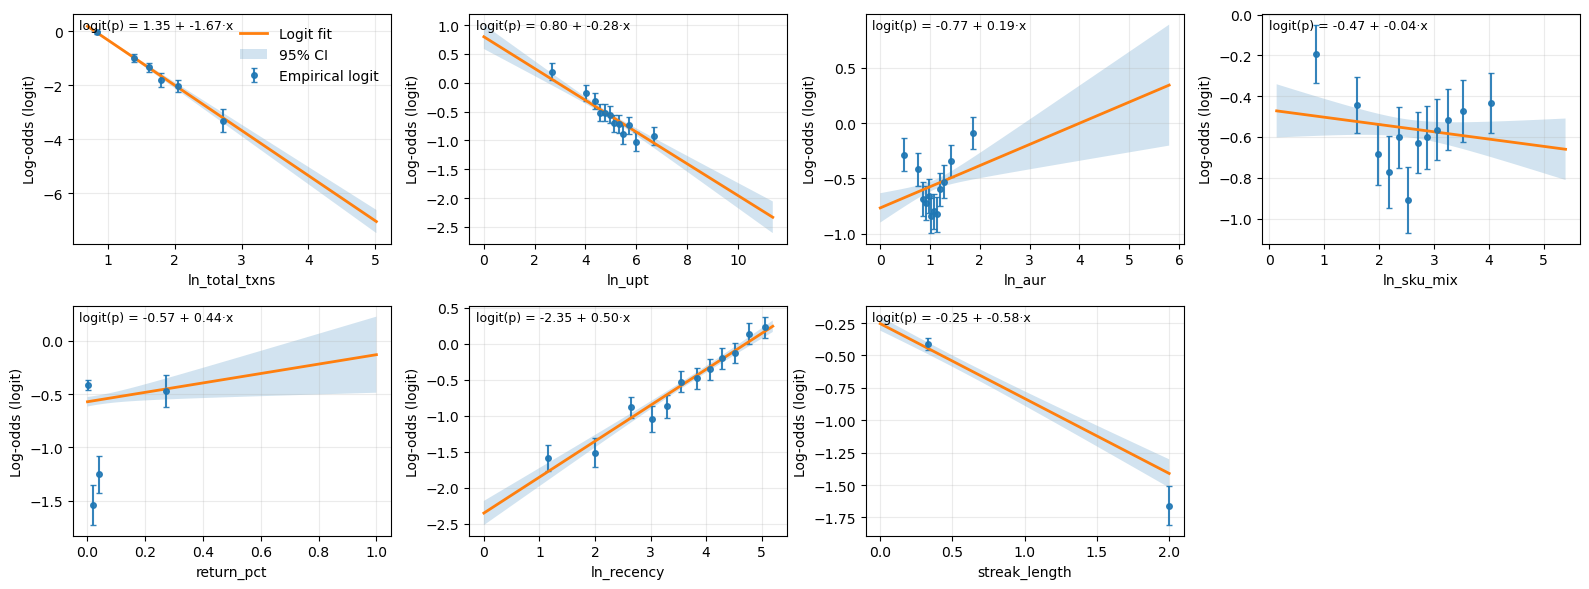

In [15]:
### Log-odds linearity plots 
# Define subplot grid
#n_cols = 4
#n_rows = int(np.ceil(len(cont_regressors) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows))
axes = axes.flatten()

# Loop through each feature
for i, col in enumerate(cont_regressors):
    ax = axes[i]
    d = df_180[[col, "churn_ind"]].copy()
    x = d[col]
    y = d["churn_ind"]

    # Fit logistic regression
    X = sm.add_constant(x) # Add intercept term
    model = sm.Logit(y, X).fit(disp=False)                          # Fit model (.fit=estimate coeficcients // disp=False suppresses print output)

    # Create quantile bins for empirical logit
    d["bin"] = pd.qcut(x, q=12, duplicates="drop")
    g = d.groupby("bin", observed=True)

    # Compute bin-level stats
    bin_n = g.size()
    x_bin = g[col].mean()
    p_bin = g["churn_ind"].mean()

    # Convert to empirical log-odds
    p_clip = np.clip(p_bin.to_numpy(), 1e-4, 1 - 1e-4)              # avoid log(0)
    logit_emp = np.log(p_clip / (1 - p_clip))
    # Approximate standard error (delta method)
    se_emp = np.sqrt(1.0 / (bin_n.to_numpy() * p_clip * (1 - p_clip)))
    z = 1.96
    lo_emp = logit_emp - z * se_emp
    hi_emp = logit_emp + z * se_emp

    # Create regression line
    xg = np.linspace(np.min(x), np.max(x), 300)
    Xg = sm.add_constant(xg)
    # Linear predictor (log-odds)
    eta_g = Xg @ model.params
    # Confidence interval for model
    cov = model.cov_params()
    se_eta_g = np.sqrt(np.sum((Xg @ cov) * Xg, axis=1))
    lo_g = eta_g - z * se_eta_g
    hi_g = eta_g + z * se_eta_g

    # Plot everything
    ax.errorbar(                                                    # Empirical logit (binned points + error bars)
        x_bin.to_numpy(),
        logit_emp,
        yerr=[logit_emp - lo_emp, hi_emp - logit_emp],
        fmt="o",
        ms=4,
        capsize=2,
        alpha=0.9,
        label="Empirical logit")
    ax.plot(xg, eta_g, linewidth=2, label="Logit fit")              # Model line
    ax.fill_between(xg, lo_g, hi_g, alpha=0.2, label="95% CI")      # Confidence band
    # Labels
    ax.set_xlabel(col)
    ax.set_ylabel("Log-odds (logit)")
    ax.grid(True, alpha=0.25)
    # Equation annotation
    b0, b1 = model.params
    ax.text(
        0.02, 0.98,
        f"logit(p) = {b0:.2f} + {b1:.2f}·x",
        transform=ax.transAxes,
        va="top",
        fontsize=9)

    # Show legend only on first plot
    if i == 0:
        ax.legend(frameon=False)

# Remove unused subplots
for j in range(len(cont_regressors), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

These plots are to help determine if the relationships between factors and churn are linear in log-odds (assumption for logistic regression).\
(If points are not linear --> indicates factor is either noise or misspecified)

Linearity diagnostics showed that several key predictors (AUR, SKU Mix, Return Pct.) exhibit nonlinear effects, leading to model misspecification in logistic regression. This motivates the use of tree-based models or nonlinear feature transformations (polynomial terms/binning).

# Fitting Models
-----------------


In [ ]:
### Define function for evaluating & model results
def evaluate_model_detailed(model, X_test, y_test, threshold=0.5, name="Model"): # Model predicts probabilities
    proba = model.predict_proba(X_test)[:, 1]                           # If exp(prob) > threshold --> then = churn
    pred = (proba >= threshold).astype(int)                             # higher threshold --> fewer churns (positives) predicted
                                                                        # Recall decreases, precision increases, coverage decrease
    print(f"\n==== {name} ====")
    # Avg. Precision: How well does the model rank churners when focusing on the positive class.
    # Usefulness when acting on predictions. Compare against population churn rate to see lift over random.
    print(f"Test Average Precision: {average_precision_score(y_test, proba):.3f}")  # Primary metric 
    # ROC-AUC: How well does the model rank churners above non-churners overall (0.5=random // 1=prefect)
    # ROC-AUC: Probability that a random churner is ranked above a random non-churner
    print(f"Test ROC-AUC: {roc_auc_score(y_test, proba):.3f}")                      # Secondary metric 
    # Dependent on threshold
    print(classification_report(y_test, pred, target_names=["Non-Churn (0)", "Churn (1)"]))

### Simplified / cleaner output function
def evaluate_model(model, X_test, y_test, threshold=0.5, name="Model"): 
    proba = model.predict_proba(X_test)[:, 1]                           
    pred = (proba >= threshold).astype(int)                             
    print(f"\n==== {name} ====")
    print(f"Test Average Precision: {average_precision_score(y_test, proba):.3f}")   
    print(f"Test ROC-AUC: {roc_auc_score(y_test, proba):.3f}")                      

    
# Split data into train & test
dft = df_180.copy()
# Train = Periods 1 and 2
train_df = dft[dft['Period'] < dft['Period'].max()].copy()
# Test = Period 3 (most recent labeled period)
test_df = dft[dft['Period'] == dft['Period'].max()].copy()

# Select input factors for modeling
regressors = ['ln_total_txns', 'ln_upt', 'ln_aur', 'ln_sku_mix','ln_recency',
              'return_pct', 'streak_length', 'UK_Ind', 
              'cx_single_purchase', 'cx_return_only', 'cx_return_txn']

X_train = train_df[regressors]
y_train = train_df['churn_ind']

X_test = test_df[regressors]
y_test = test_df['churn_ind']

Because churn prediction is an imbalanced classifcation problem, I prioritized Avg. Precision over ROC-AUC, since Avg. Precision focuses on performance for churners (positive class) and better reflects targeting effectiveness.

Note: PR-AUC (Precision-Recall Area Under the Curve) ignores true negatives, focusing only on the precision and recall of the positive class. ROC-AUC often look excellent on imbalanced data because they include the false positive rate, which remains low when true negatives are high. PR-AUC gives a harsher, more realistic, and more informative view of performance, as it is more sensitive to false positives.

## Logistic Regression

In [17]:
### Scale continuous regressors for Logistic Regression
# Helps convergence of model & reduces bais influenced by factors measured on greater scales.
binary_features = [
    col for col in X_train.columns
    if X_train[col].dropna().nunique() == 2
]

numeric_features = [
    col for col in X_train.columns
    if col not in binary_features
]

X_train_scaled = X_train.copy() 
X_train_scaled[numeric_features] = StandardScaler().fit_transform(X_train[numeric_features])
X_test_scaled = X_test.copy() 
X_test_scaled[numeric_features] = StandardScaler().fit_transform(X_test[numeric_features])

In [18]:
## fit logistic regression   (using statsmodels ~ sm for interpretability)          
X_train_sm = sm.add_constant(X_train_scaled)
result = sm.Logit(y_train, X_train_sm).fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.582052
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:              churn_ind   No. Observations:                 6175
Model:                          Logit   Df Residuals:                     6163
Method:                           MLE   Df Model:                           11
Date:                Thu, 09 Apr 2026   Pseudo R-squ.:                  0.1313
Time:                        08:42:56   Log-Likelihood:                -3594.2
converged:                       True   LL-Null:                       -4137.4
Covariance Type:            nonrobust   LLR p-value:                4.926e-226
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -0.7690      0.117     -6.598      0.000      -0.997      -0.541
ln_to

Model interpretation:
- Magnitude and sign of variables are consistent with findings from univariate logistic regression plots, with the exception of AUR.
- AUR showed a positive relationship with churn in univariate analysis, but its coefficient flipped in a multivariate model. This is because AUR is correlated with other behavioral variables (UPT & Recency). After controlling for confounding factors, higher AUR is associated with lower churn risk.
- SKU Mix, Geography (UK_Ind), & two customer type categories are not statistically significant\
 (single purchase customers & customers with > 1 return) & could be removed from the model.


In [19]:
## fit logistic regression (using sklearn for comparison with Gradient Boosting Classification models)   
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)

# Evaluate model
evaluate_model_detailed(log_reg, X_test_scaled, y_test, name="Logistic Regression")


==== Logistic Regression ====
Test Average Precision: 0.418
Test ROC-AUC: 0.703
               precision    recall  f1-score   support

Non-Churn (0)       0.82      0.67      0.74      1883
    Churn (1)       0.46      0.66      0.54       795

     accuracy                           0.67      2678
    macro avg       0.64      0.67      0.64      2678
 weighted avg       0.72      0.67      0.68      2678



## Gradient Boosting Classification

### Hyperparameter Tuning - Random Search

In [20]:
# Define the parameter space this will be searched & tested (at random) to determine the best paramater values 
param_distributions = {
    ### Function Shape
    "learning_rate": loguniform(0.01, 0.2),                     # Contribution of each tree
    "n_estimators": randint(50, 800),                           # Number of boosting stages/trees
    ### Tree shapes
    "max_depth": randint(3, 9),                                  # Deeper trees capture more interactions (but overfit quickly)
    "min_samples_split": loguniform(0.001, 0.1),                # Should depend on dataset size (min split log spacespace from 0.1% to 10% of samples)
    "min_samples_leaf": loguniform(0.001, 0.05),                # Minimum samples in each each leaf
    ### 
    "subsample": uniform(0.5, 1-0.5),                               # Fraction of rows to use for each tree
    #"max_features": ["sqrt", "log2", None],                    # Use only a subset of features for each tree (avoids single factor dominating each tree)
    "max_features": [None]                                      # Use none if feature set is small (<20)
}


r_search = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=1,
                                        n_iter_no_change=15,
                                        validation_fraction=0.1,
                                        tol=1e-4),
    param_distributions=param_distributions,
    n_iter=60,
    scoring="average_precision",                    # Area under Precision-Recall curve
            #"recall"                               # To catch them all - use if missing a churn cost much higher than false positive
            #"f1"                                   # Balance between Precision and Recall
            #"roc_auc"                              # Standard - Ability to distinguish classes but can be misleadingly high if data is imbalanced
    # Cross validation splits your data into n chunks. It trains on n-1 and tests on 1
    cv= StratifiedKFold(n_splits=5, shuffle=True, random_state=1), 
    random_state=1,
    n_jobs=-1,
    verbose=1,                          # Show progress bar to see how many fits are left
    refit=True,                         # After the search finds the best parameters, take those settings & retrains model on entire dataset
)

r_search.fit(X_train, y_train)
b_r_search = r_search.best_estimator_

# Evaluate model
evaluate_model_detailed(b_r_search, X_test, y_test, name="GBM - Random Search")


Fitting 5 folds for each of 60 candidates, totalling 300 fits

==== GBM - Random Search ====
Test Average Precision: 0.461
Test ROC-AUC: 0.729
               precision    recall  f1-score   support

Non-Churn (0)       0.80      0.73      0.76      1883
    Churn (1)       0.47      0.56      0.51       795

     accuracy                           0.68      2678
    macro avg       0.63      0.65      0.64      2678
 weighted avg       0.70      0.68      0.69      2678



In [21]:
# A faster verison of the same thing using HistGradientBoostingClassifier
n = X_train.shape[0]
# Calculate absolute row counts for your bounds
# Ensure the min is at least 1 and the max is at least min + 1
min_leaf_lower = max(1, int(n * 0.001)) 
min_leaf_upper = max(min_leaf_lower + 1, int(n * 0.05))
max_leaf_upper = max(16, min(255, n // 100))


# HGBC grows trees leaf-wise (best-first), whereas GBC typically grows them level-wise. 
# Leaf-wise growth is more flexible and efficient for large datasets but requires max_leaf_nodes to be carefully tuned to prevent deep, overfit branches.
hist_param_distributions = {
    ### Function Shape
    "learning_rate": loguniform(0.01, 0.3),                         # Contribution of each tree (use wider range for HGBC)
    "max_iter": randint(100, 1000),                                 # Number of boosting stages/trees (Note: max_iter == n_estimators) set high due to early_stopping=True.
    
    ### Tree shapes
    # Don't let trees have more leaves than 1/100th of your data, maxed at 255
    "max_leaf_nodes": randint(15, max_leaf_upper),                  # HGBC prioritize max_leaf_nodes over max_depth
    "min_samples_leaf": randint(min_leaf_lower, min_leaf_upper),    # Minimum samples in each each leaf

    # HGBC uses its internal histogram logic and early stopping to manage variance instead of row-based subsampling.
    # max_bins defaults to 255 - Test if "coarser" features help generalization
    "max_bins": randint(32, 255),                                   # Binning granularity

    # Prevent overfitting by penalizing large weights - adds penalty proportional to the square of the magnitude of the model's coefficients to the loss function
    "l2_regularization": loguniform(1e-6, 10.0)  
}


hist_search = RandomizedSearchCV(
                estimator=HistGradientBoostingClassifier(
                random_state=1,
                early_stopping=True,
                validation_fraction=0.1,            # For early stop, model needs to test itself on data it hasn't seen. It trains on 90%, then checks its score on this 10%
                n_iter_no_change=15,                # How many trees the model is willing to build without seeing an improvement before it gives up
                tol=1e-4                            # "Tolerance" // what counts as a "real" improvement
                    # Note: If learning_rate is extremely small (~0.001), model might improve so slowly that it triggers tol and stops too early. 
                    # If using tiny learning rate, one should also make tol smaller or n_iter_no_change larger. 
                ),
    param_distributions=hist_param_distributions,
    n_iter=60,
    scoring="average_precision",                    # Area under Precision-Recall curve
            #"recall"                               # To catch them all - use if missing a churn cost much higher than false positive
            #"f1"                                   # Balance between Precision and Recall
            #"roc_auc"                              # Standard - Ability to distinguish classes but can be misleadingly high if data is imbalanced
    # Cross validation splits your data into n chunks. It trains on n-1 and tests on 1
    cv= StratifiedKFold(n_splits=5, shuffle=True, random_state=1), 
    random_state=1,
    n_jobs=-1,
    verbose=1,                          # Show progress bar to see how many fits are left
    refit=True,                         # After the search finds the best parameters, take those settings & retrains model on entire dataset
)

hist_search.fit(X_train, y_train)
b_hist_search = hist_search.best_estimator_

# Evaluate model
evaluate_model_detailed(b_hist_search, X_test, y_test, name="GBM - Histogram Search")

Fitting 5 folds for each of 60 candidates, totalling 300 fits

==== GBM - Histogram Search ====
Test Average Precision: 0.453
Test ROC-AUC: 0.719
               precision    recall  f1-score   support

Non-Churn (0)       0.81      0.68      0.74      1883
    Churn (1)       0.45      0.63      0.52       795

     accuracy                           0.66      2678
    macro avg       0.63      0.65      0.63      2678
 weighted avg       0.70      0.66      0.67      2678



### Hyperparameter Tuning - Bayesian Optimization


In [22]:
# Define objective function (the thing we are optimizing with bayesian decent)
def objective_hgb(trial):
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_iter": trial.suggest_int("max_iter", 100, 1000),
        "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 15, max_leaf_upper),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", min_leaf_lower, min_leaf_upper),
        "max_bins": trial.suggest_int("max_bins", 32, 255),
        "l2_regularization": trial.suggest_float("l2_regularization", 1e-6, 10.0, log=True),
    }

    model = HistGradientBoostingClassifier(
        **params,                                       # note: ** --> dict unpacking
        random_state=1,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        tol=1e-3
    )

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=1),
        scoring="average_precision",
        n_jobs=-1
    )

    return scores.mean()            # Optuna needs single scalar to optimize

# Repress optuna output (keep warnings & errors)
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Run the study (study == entire optimization process)
    # Study contains all trials (each hyperparameter combo), scores, best result so far & search strategy.
study_hgb = optuna.create_study(direction="maximize")

# Each trial hyperparameters selected strategically, calls objective function (getting score), & informs model for performance improvements
study_hgb.optimize(objective_hgb, n_trials=300, show_progress_bar=True)      # Find best parameters using cross validation
print("Best params:", study_hgb.best_params)

# Fit final model using best found parameter set
b_hgb_bayes = HistGradientBoostingClassifier(                           
    **study_hgb.best_params,
    random_state=1,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    tol=1e-3
)
b_hgb_bayes.fit(X_train, y_train)

# Evaluate model
evaluate_model_detailed(b_hgb_bayes, X_test, y_test, name="GBM - Bayesian Optimization")

Best trial: 226. Best value: 0.588572: 100%|██████████| 300/300 [01:12<00:00,  4.16it/s]


Best params: {'learning_rate': 0.01075708533009258, 'max_iter': 512, 'max_leaf_nodes': 16, 'min_samples_leaf': 168, 'max_bins': 216, 'l2_regularization': 0.008502889578194662}

==== GBM - Bayesian Optimization ====
Test Average Precision: 0.464
Test ROC-AUC: 0.730
               precision    recall  f1-score   support

Non-Churn (0)       0.83      0.69      0.75      1883
    Churn (1)       0.47      0.65      0.55       795

     accuracy                           0.68      2678
    macro avg       0.65      0.67      0.65      2678
 weighted avg       0.72      0.68      0.69      2678



# Comparing Models & Interpreting Results
---------------------------

## Model Results

In [23]:
print(f"Train churn rate: {100 * y_train.mean():.1f}%")
print(f"Test churn rate: {100 * y_test.mean():.1f}%")

evaluate_model(log_reg, X_test_scaled, y_test, name="Logistic Regression")
evaluate_model(b_r_search, X_test, y_test, name="Gradient Boosting Classifier")
evaluate_model(b_hist_search, X_test, y_test, name="Hist Gradient Boosting Classifier")
evaluate_model_detailed(b_hgb_bayes, X_test, y_test, name="Bayesian Optimzation Hist-GBC")

Train churn rate: 39.3%
Test churn rate: 29.7%

==== Logistic Regression ====
Test Average Precision: 0.418
Test ROC-AUC: 0.703

==== Gradient Boosting Classifier ====
Test Average Precision: 0.461
Test ROC-AUC: 0.729

==== Hist Gradient Boosting Classifier ====
Test Average Precision: 0.453
Test ROC-AUC: 0.719

==== Bayesian Optimzation Hist-GBC ====
Test Average Precision: 0.464
Test ROC-AUC: 0.730
               precision    recall  f1-score   support

Non-Churn (0)       0.83      0.69      0.75      1883
    Churn (1)       0.47      0.65      0.55       795

     accuracy                           0.68      2678
    macro avg       0.65      0.67      0.65      2678
 weighted avg       0.72      0.68      0.69      2678



__Temporal Drift Issue:__\
As observe above, there is a shift in churn rate between training and test periods, indicating temporal changes in customer behavior. T Rather than correcting for it, we intentionally preserved this structure to simulate real-world deployment. The model still performs well on PR-AUC, suggesting it captures stable ranking signals. In production, I would address this through periodic retraining and probability calibration.

__Model Comparison:__
- Gradient Boosting model resulated in a ~10% lift in Avg. Precision over Logistic Regression model (PR-AUC: 0.418 → 0.464)


__Model Interpretation:__
- At a threshold of 0.50, the model correctly categorizes 65% (recall) of churners, however approx. half (53%) of the predicted churners are actually non-churners (precision).

__Note:__
- Precision (0.47): When the model flags a customer as a churner, it is only right 47% of the time --> (many false positives).
- Recall (0.65): Out of all actually churnedrs, model caught 65% of them. Missing ~35% (False Negatives).
- F1-Score (0.55): Harmonic mean of the two scores

In [30]:
# Get probabilities from your BEST model
y_prob = b_hgb_bayes.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.0, 0.95 + 0.05, 0.05)

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    
    # Skip if no positives predicted
    if y_pred.sum() == 0:
        continue
    
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    
    # Coverage = % of customers flagged as churn
    coverage = y_pred.mean()

    # Overall model performance: 
    avg_prec = average_precision_score(y_test, y_pred)
    
    print(f"Threshold={t:.2f} | Coverage={coverage:.1%} | Precision={precision:.2f} | Recall={recall:.2f}")#  | Avg. Precision={avg_prec:.2f}")

Threshold=0.00 | Coverage=100.0% | Precision=0.30 | Recall=1.00
Threshold=0.05 | Coverage=100.0% | Precision=0.30 | Recall=1.00
Threshold=0.10 | Coverage=93.7% | Precision=0.32 | Recall=1.00
Threshold=0.15 | Coverage=89.4% | Precision=0.33 | Recall=0.99
Threshold=0.20 | Coverage=85.1% | Precision=0.34 | Recall=0.98
Threshold=0.25 | Coverage=81.0% | Precision=0.35 | Recall=0.97
Threshold=0.30 | Coverage=74.4% | Precision=0.37 | Recall=0.93
Threshold=0.35 | Coverage=68.1% | Precision=0.40 | Recall=0.91
Threshold=0.40 | Coverage=59.8% | Precision=0.42 | Recall=0.85
Threshold=0.45 | Coverage=50.2% | Precision=0.45 | Recall=0.75
Threshold=0.50 | Coverage=41.0% | Precision=0.47 | Recall=0.65
Threshold=0.55 | Coverage=25.3% | Precision=0.50 | Recall=0.42
Threshold=0.60 | Coverage=10.0% | Precision=0.45 | Recall=0.15
Threshold=0.65 | Coverage=1.1% | Precision=0.60 | Recall=0.02


__Targeting Scenarios at different thresholds:__\
While 29.7% of P3 customers churn in P4, the model can be used to:
- Target ~10% of customers with 45% precision, capturing 15% of churners.
- Target ~50% of customers with 42% precision, capturing 75% of churners.

This indicated that coverage can be increased substantially while maintaining relatively stable precision, enabling significantly higher recall.

While the model has moderate classification performance, it provides strong value as a ranking tool, enabling targeted retention strategies that significantly outperform random selection. The optimal coverage threshold depends on business constraints:
- If outreach cost is low (including cost of targeting non-churners), a lower threshold (higher recall) is preferred.
- If outreach is expensive, a higher threshold (higher precision) is more appropriate.

Note:
- Threshold: Model's expected probability cut-off level for classifying a prediction as churn.
- Coverage: Percent of customers the model categorized as predicted churners.
- Precision: Of those the model categorized as churners, how many actually churned.
- Recall: Percent of Churners that are actually caught

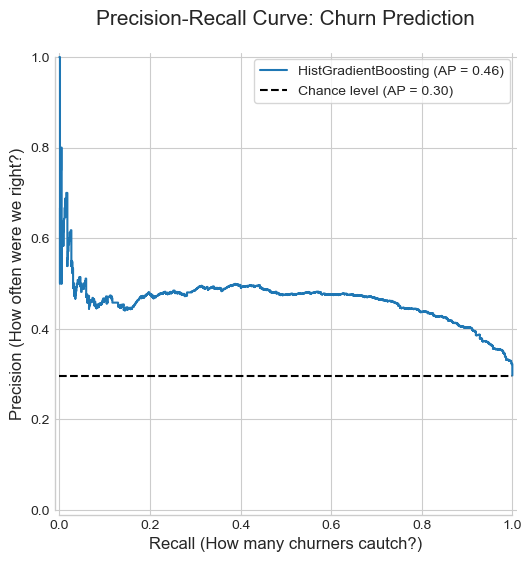

In [25]:
# Set a nice style (optional)
plt.style.use('seaborn-v0_8-whitegrid') 

# Create the plot using the best model from  search
fig, ax = plt.subplots(figsize=(8, 6))

display = PrecisionRecallDisplay.from_estimator(
    b_hgb_bayes, 
    X_test, 
    y_test, 
    name="HistGradientBoosting",
    plot_chance_level=True,  # Shows the baseline for imbalanced data
    despine=True,            # Removes top/right borders for a cleaner look
    ax=ax
)

# 2. Add custom styling to make it "pretty"
ax.set_title("Precision-Recall Curve: Churn Prediction", fontsize=15, pad=20)
ax.set_xlabel("Recall (How many churners cautch?)", fontsize=12)
ax.set_ylabel("Precision (How often were we right?)", fontsize=12)
ax.legend(loc="upper right", frameon=True)

plt.show()

The steep, early drop-off indicates the model is not effective as a high accuracy classifier. However, the model maintains stable precision across a wide recall range (0.2 to 0.7), achieves ~50% lift over random targeting. Making it well-suited for scalable targeting strategies with precision remaining around 45–50%.

## Quantifying factor importance: SHAP values

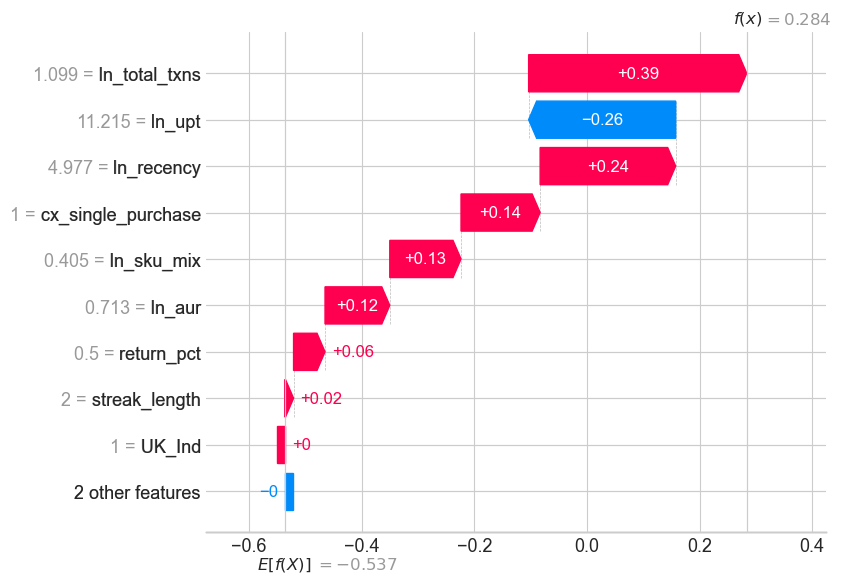

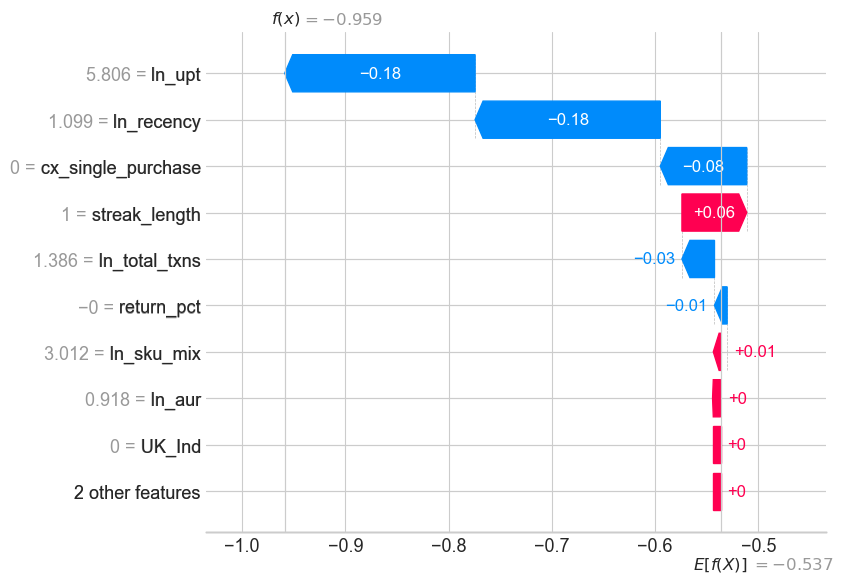

In [37]:
explainer = shap.Explainer(model=b_hgb_bayes)
shap_values = explainer(X_test)

# Waterfall plot shows how bosting cunction gets from base_values (weak predection) to predicted value
for i in range(0,2):
    shap.plots.waterfall(shap_values[i])
    

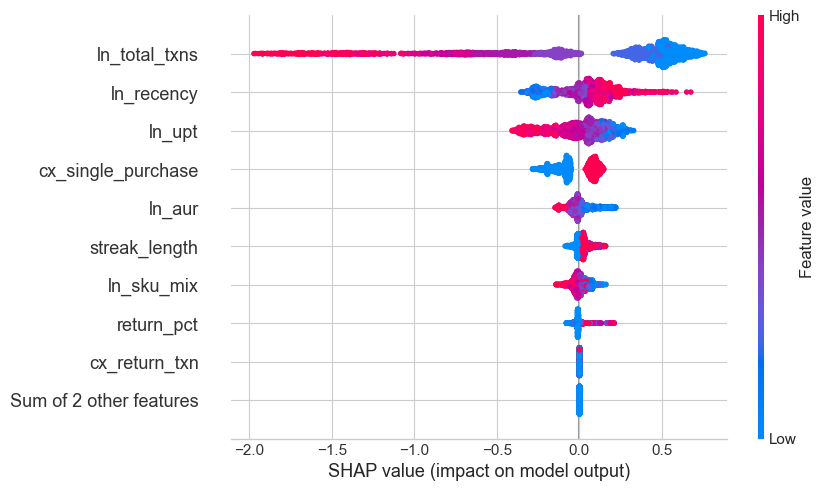

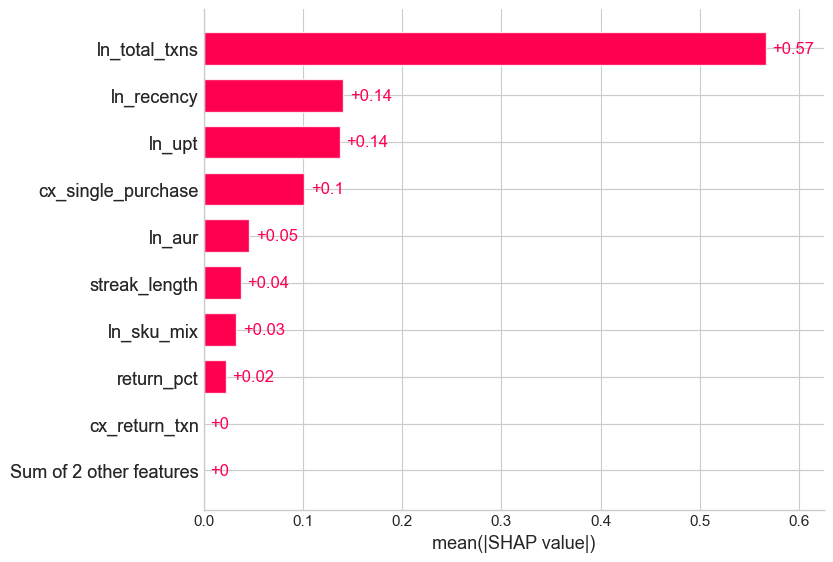

In [27]:
# Beeswarm (global feature importance)
shap.plots.beeswarm(shap_values)

# Bar plot (mean importance)
shap.plots.bar(shap_values)

# ~ Further Analysis
-----------------------------------

Opportunities:
- Improved CRM (fill in missing Customer ID or identify source of missing values)
- Customer type identification (+ capture additional customer details)
- Increase time scale to examine if seasonality is a factor as well as more detailed customer typing (new vs. churned vs. returning vs. repeating)
- Current model prediction accuracy for "high value" customers & estimate business value of different retention campaigns
- Analysis of product types

## ~ Segmentation: Predicting churn for high value customers

## ~ Temporal Factors